In [3]:
import numpy as np

gmm = np.load('gmm_descriptor.npy')
scm = np.load('scm_descriptor.npy')
copula = np.load('copula_descriptor.npy')

In [4]:
X_train = np.concatenate([gmm, scm, copula],axis=0)
print(X_train.shape)

(3000, 1024)


2D reduced shape: (3000, 2)
Explained variance ratio: [0.38417667 0.3590986 ]


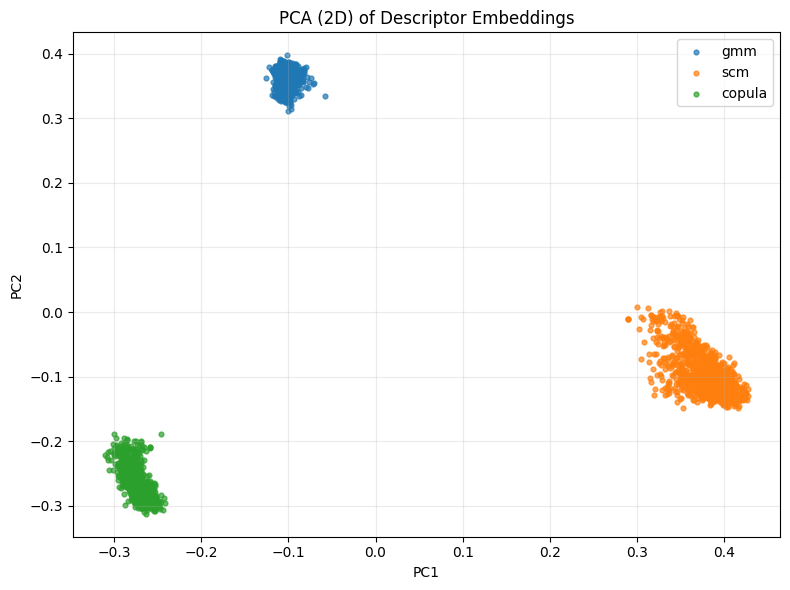

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit PCA to 2D on all training embeddings (no train/test split)
pca2 = PCA(n_components=2, random_state=42)
X_train_pca2 = pca2.fit_transform(X_train)

print("2D reduced shape:", X_train_pca2.shape)
print("Explained variance ratio:", pca2.explained_variance_ratio_)

# Build labels by source block order used in X_train concatenation
n_gmm = len(gmm)
n_scm = len(scm)
n_copula = len(copula)

labels = np.array(["gmm"] * n_gmm + ["scm"] * n_scm + ["copula"] * n_copula)

plt.figure(figsize=(8, 6))
for name, color in [("gmm", "tab:blue"), ("scm", "tab:orange"), ("copula", "tab:green")]:
    m = labels == name
    plt.scatter(X_train_pca2[m, 0], X_train_pca2[m, 1], s=12, alpha=0.7, label=name, c=color)

plt.title("PCA (2D) of Descriptor Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [11]:
import joblib
# 4) Fit PCA once
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)

print("Reduced shape:", X_train_pca.shape)   # (n_samples, 100)

# 5) Save PCA for reuse
joblib.dump(pca, "pca_100.joblib")

ValueError: n_components=100 must be between 0 and min(n_samples, n_features)=1 with svd_solver='full'

In [15]:
import joblib
pca = joblib.load("pca_100.joblib")
X_train_pca = pca.transform(X_train[0:1])

In [16]:
print("Reduced shape:", X_train_pca.shape)

Reduced shape: (1, 100)
